<a href="https://colab.research.google.com/github/TatianaLot/YP_projectmonth_1/blob/master/model_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование риска сердечного приступа

**Цели исследования:** анализ факторов риска сердечного приступа и построение модели для предсказания риска сердечного приступа

**Задачи исследоввания:**
1. Загрузка тренировочных данных
2. Изучение и предобработка тренировночнх данных
3. Исследовательский анализ данных
4. Корреляционный анализ данных
5. Обучение моделей, выбор наилучшей модели исходя из целевой метрики на валидационноый выборке
6. Аналиж важности признаков и общие выводы по модели
7. Получение предсказания для тестовой выборки

**Описание данных:** тренировочные данные из открытого источника, сгенерированные ИИ

In [1]:
pip install phik -q

In [44]:
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
import numpy as np
from google.colab import files, drive
import phik

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder,  FunctionTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score,\
precision_recall_curve, ConfusionMatrixDisplay

import joblib
import json
from datetime import datetime
import time
import os

RANDOM_STATE = 16

## Загрузка и общая информация о данных

In [52]:
# Загрузка файлов
drive.mount('/content/drive', force_remount=False)
DRIVE_FOLDER = '/content/drive/MyDrive/heart_model'
filename_train = 'heart_train.csv'
filename_test = 'heart_test.csv'

file_path_train = f'{DRIVE_FOLDER}/{filename_train}'
file_path_test = f'{DRIVE_FOLDER}/{filename_test}'
df = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Посмотрим содержимое данных
df.head(10)

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047
5,5,0.168539,0.764286,0.057745,0.0,1.0,1.0,1.0,1.0,0.082682,...,6.0,0.833333,0.0,0.227018,0.048229,0.036512,Male,0.464516,0.418605,5817
6,6,0.483146,0.021429,0.036664,1.0,0.0,1.0,0.0,1.0,0.540206,...,5.0,0.000000,1.0,0.231225,0.008940,0.000291,Male,0.361290,0.569767,5580
7,7,0.235955,0.939286,0.081577,1.0,0.0,1.0,0.0,1.0,0.290837,...,4.0,0.000000,0.0,0.227018,0.048229,0.036512,Male,0.690323,0.639535,4963
8,8,0.685393,0.317857,0.039413,0.0,0.0,1.0,0.0,0.0,0.803160,...,6.0,0.166667,1.0,0.126482,0.002332,0.007185,Male,0.664516,0.616279,4521
9,9,0.213483,0.796429,0.076994,1.0,1.0,1.0,1.0,0.0,0.506971,...,3.0,1.000000,0.0,0.227018,0.048229,0.036512,Male,0.651613,0.720930,2455


Данные в целом соответствуют названиям переменных, хотя по части переменных данные нормализованы, поэтому сложно сделать вывод о том, насколько их диапазоны до нормализации соответствуют значениям переменных.

Отдельно необходимо обратить внимание на столбец Unnamed, который вероятно получился из индекса и теперь дублирует индекс.

In [ ]:
# Посмотрим список переменных в файле
df.columns.tolist()

['Unnamed: 0',
 'Age',
 'Cholesterol',
 'Heart rate',
 'Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Exercise Hours Per Week',
 'Diet',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Heart Attack Risk (Binary)',
 'Blood sugar',
 'CK-MB',
 'Troponin',
 'Gender',
 'Systolic blood pressure',
 'Diastolic blood pressure',
 'id']

Названия переменных местами с большой буквы и с пробелами вместо нижних подчеркиваний

In [ ]:
# Общая информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

Почти все переменные числовые, кроме диеты и id (целочисленные) и пола (строка)

In [ ]:
# Пропуски
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Unnamed: 0                           0
Age                                  0
Cholesterol                          0
Heart rate                           0
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Exercise Hours Per Week              0
Diet                                 0
Previous Heart Problems            243
Medication Use                     243
Stress Level                       243
Sedentary Hours Per Day              0
Income                               0
BMI                                  0
Triglycerides                        0
Physical Activity Days Per Week    243
Sleep Hours Per Day                  0
Heart Attack Risk (Binary)           0
Blood sugar                          0
CK-MB                                0
Troponin                             0
Gender                          

## Предобработка данных

In [ ]:
# Проверка уникальности id
df['id'].nunique()

8685

Комментарий: с id нет проблем с уникальностью, т.к. количество уникальных вариантов совпадает с количеством строк в дф. Сделаем его индексом в пайплайне

In [ ]:
# Проверка неявных дубликатов по категориальным переменным
for column in df.select_dtypes(include=['object']).columns:
    print(f"\n--- Столбец: {column} ---")
    print(f"Тип данных: {df[column].dtype}")
    print("Распределение значений:")
    print(df[column].unique())
    print(f"Количество уникальных значений: {df[column].nunique()}")


--- Столбец: Gender ---
Тип данных: object
Распределение значений:
['Male' 'Female' '1.0' '0.0']
Количество уникальных значений: 4


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,5882
Female,2560
1.0,156
0.0,87


Комментарий: в переменной "пол" помимо Male и Female присутствуют странные значения 1 и 0, для которых непонятно, какой пол.Чтобы убрать неявные дубликаты, но надо определить (предположить) для 1 и 0, где какой пол.  Даже если сделать это не получится, то это несущественная проблема, потому что таких данных немного, поэтому можно просто убрать их.

In [ ]:
# Попробуем определить пол по среднему доходу (по статистике почти по всем странам выше доход у мужчин) и пульсу (выше пульс у мужчин)
pivot_gender = df[['Gender','Income', 'Heart rate', 'Smoking', 'Alcohol Consumption']].\
pivot_table(index= 'Gender', aggfunc = 'mean').round(2)
display(pivot_gender)

,Alcohol Consumption,Heart rate,Income,Smoking
Gender,,,,
0.0,NaN,0.08,0.49,NaN
1.0,NaN,0.06,0.49,NaN
Female,0.61,0.05,0.49,0.68
Male,0.60,0.05,0.50,1.00


In [ ]:
# Попробуем посмотреть пол по курению
crosstab_gender = pd.crosstab(df['Gender'], df['Smoking'])
display(crosstab_gender)

Smoking,0.0,1.0
Gender,,
Female,820,1740
Male,0,5882


In [ ]:
# Попробуем посмотреть пол по употреблению алкоголя
crosstab_gender = pd.crosstab(df['Gender'], df['Alcohol Consumption'])
display(crosstab_gender)

Alcohol Consumption,0.0,1.0
Gender,,
Female,1002,1558
Male,2358,3524


Для пола 0 и 1 данные по курению и употреблению алкоголя вообще не заполнены, по переменным с доходом и сердечным ритмом сложно сделать однозначный вывод о поле для 1 и 0, потому что существенных отличий нет. Эти данные лучше совсем удалить

In [ ]:
# Изучим пропуски в данных, предполагаю, что они в одних и тех же строках
missing_df = df.isnull()
cols_check = df.columns[df.isnull().any()].tolist()

for i in range(len(cols_check)):
    for j in range(i + 1, len(cols_check)):
        col1, col2 = cols_check[i], cols_check[j]
        ct = pd.crosstab(missing_df[col1], missing_df[col2])
        print(f"\n--- Пропуски: {col1} vs {col2} ---")
        print(ct)



--- Пропуски: Diabetes vs Family History ---
Family History  False  True 
Diabetes                    
False            8442      0
True                0    243

--- Пропуски: Diabetes vs Smoking ---
Smoking   False  True 
Diabetes              
False      8442      0
True          0    243

--- Пропуски: Diabetes vs Obesity ---
Obesity   False  True 
Diabetes              
False      8442      0
True          0    243

--- Пропуски: Diabetes vs Alcohol Consumption ---
Alcohol Consumption  False  True 
Diabetes                         
False                 8442      0
True                     0    243

--- Пропуски: Diabetes vs Previous Heart Problems ---
Previous Heart Problems  False  True 
Diabetes                             
False                     8442      0
True                         0    243

--- Пропуски: Diabetes vs Medication Use ---
Medication Use  False  True 
Diabetes                    
False            8442      0
True                0    243

--- Пропуски: Diabe

Пропуски в одних и тех же строках. В целом можно было бы их удалить, потому что их немного.

**Выводы:** всего в дф 8685 строк, из которых в 243 пропущены данные по ряду количественных переменных (9 переменных). Также в переменной "пол" в этих же строках содержатся данные 1 и 0, которые невозможно категоризировать по полу. Эти строки предпочтительно удалить.

## Исследовательский анализ данных

In [5]:
# Сделаем дф для анализа без пропусков и без лишних значений в переменной "пол"
df_eda = df.dropna()
df_eda = df_eda.query('Gender == "Male" or Gender == "Female"')

In [6]:
# Создание нового индекса
df_eda = df_eda.reset_index()
df_eda = df_eda.drop('Unnamed: 0', axis=1)
df_eda.sort_values(by = 'id')
df_eda = df_eda.set_index('id')

In [9]:
# Функция для анализа количественных переменных
def quantitative_description(data, columns):
    for column in columns:
        col_name = column
        print(f'Описательная статистика по переменной: {col_name}')
        display(data[column].describe())
        fig = px.histogram(data, x=column)
        fig.update_layout(
        xaxis_title=col_name,
        yaxis_title='Количество наблюдений',
        title = f'Гистограмма по переменной: {col_name}')
        fig.show()
        fig = px.box(data, x=column)
        fig.update_layout(
        xaxis_title=col_name,
        title = f'Диаграмма размаха по переменной: {col_name}')
        fig.show()

In [10]:
# Описательная статистика по количественным переменным
num_col =  df_eda.select_dtypes(include=float)
quantitative_description(df_eda, num_col)

Описательная статистика по переменной: Age


,Age
count,8442.000000
mean,0.449008
std,0.232809
min,0.044944
25%,0.247191
50%,0.460674
75%,0.640449
max,0.853933


Описательная статистика по переменной: Cholesterol


,Cholesterol
count,8442.000000
mean,0.501108
std,0.288785
min,0.000000
25%,0.260714
50%,0.496429
75%,0.750000
max,1.000000


Описательная статистика по переменной: Heart rate


...

,Troponin
count,8442.000000
mean,0.036867
std,0.059284
min,0.000000
25%,0.036512
50%,0.036512
75%,0.036512
max,1.000000


Описательная статистика по переменной: Systolic blood pressure


,Systolic blood pressure
count,8442.000000
mean,0.451955
std,0.170187
min,0.161290
25%,0.303226
50%,0.451613
75%,0.600000
max,0.741935


Описательная статистика по переменной: Diastolic blood pressure


,Diastolic blood pressure
count,8442.000000
mean,0.501672
std,0.170302
min,0.209302
25%,0.348837
50%,0.500000
75%,0.651163
max,0.790698


**Общий комментарий:** По всем переменным равномерное распределение, что странно для многих показателей. Кроме того, после нормализации сложно сделать вывод о том, насколько сами значения переменных являются правдоподобными. Также в данных есть три переменные, в которых более 78% записей имеют одинаковое значение, то есть вероятно пропуски были заполнены типичным значением.

**Детати по переменным:**
Возраст: распределение по возрасту достаточно равномерное, нет выраженных пиков. При этом сложно сказать, какого именно возраста представлены пациенты, потому что данные по переменной нормализованы.

Холестерол: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Сердечный ритм: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Количество часов упражнений в день: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.
Уровень стресса: в переменной всего 10 дискретных значений, она является категориальной, а не количественной. Также кажется странным отсутствие пиков вокруг типичных значений.

Малоподвижные часы в день: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Доход: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Индекс массы тела: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Триглицериды: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.

Количество дней физической активности в неделю: в переменной всего 8 дискретных значений, она является категориальной, а не количественной. Также кажется странным отсутствие пиков вокруг типичных значений.

Часы сна в день: в переменной несколько дискретных значений, но она была нормализована, поэтому оставим ее количественной. Также кажется странным отсутствие пиков вокруг типичных значений.

Уровень сахара в крови: имеет выраженный пик на одном значении – 78% имеют данное значений. Предположительно, это были пропуски в данных, которые были заполнены каким-то типичным значением.

СК-МВ (креатинкиназа МВ): имеет выраженный пик на одном значении – 78% имеют данное значений. Предположительно, это были пропуски в данных, которые были заполнены каким-то типичным значением. При этом данная переменная не должна использоваться в модели машинного обучения, т.к. искажения в ее значениях возникают только ПОСЛЕ сердечного приступа.

Тропонин: имеет выраженный пик на одном значении – 78% имеют данное значений. Предположительно, это были пропуски в данных, которые были заполнены каким-то типичным значением. При этом данная переменная не должна использоваться в модели машинного обучения, т.к. искажения в ее значениях возникают только ПОСЛЕ сердечного приступа.

Систолическое и диастолическое артериальное давление: распределение по переменной достаточно равномерное, нет выраженных пиков. Переменная также была нормализована, поэтому сложно проверить значения на соответствие обычным для данного показателя. Однако кажется странным отсутствие пиков вокруг типичных значений.


Некоторые переменные явно бинарные и надо их сделать bool, также есть категориальные переменные, у которых надо изменить тип, а также есть переменная с диетой, которую лучше рассматривать как номинальную

In [7]:
binary_cols = ['Diabetes','Family History', 'Smoking','Obesity', 'Alcohol Consumption', 'Previous Heart Problems',\
               'Medication Use']


df_eda[binary_cols] = df_eda[binary_cols].astype('object')

In [8]:
ordinal_cols = ['Physical Activity Days Per Week', 'Stress Level']
df_eda[ordinal_cols] = df_eda[ordinal_cols].astype('category')

In [9]:
nominal_cols = ['Diet']
df_eda[ordinal_cols] = df_eda[ordinal_cols].astype('object')

In [ ]:
# Функция для исследования категориальных переменных
def nom_analysis(data):
    for column in data.select_dtypes(include=['object', 'bool', 'category']):
        col_name = column
        fig = px.bar(data[column].value_counts(normalize = True).round(2))
        fig.update_traces(texttemplate='%{y}', textposition='outside')
        fig.update_layout(
        xaxis_title=col_name,
        yaxis_title='Доля наблюдений',
        title= f'Распределение по переменной: {col_name}')
        fig.show()


In [ ]:
object_col =  df_eda.select_dtypes(include=['object', 'bool', 'category'])
nom_analysis(df_eda)

**Общий комментарий:** описательная статистика по категориальным переменным вызывает сомнения относительно репрезентативности данных.

**Детальные комментарии:**
Диабет: 65% имеет значение 1, а 35% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.

Семейные факторы риска: 51% имеет значение 1, а 49% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.

Курение: 90% имеет значение 1, а 10% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна. Однако, возможно, что 1 обозначает, что пациент не курит. При этом также странным является распределение по полу – среди женщин только некурящие, что опять же не является репрезентативным.

Ожирение: 50% имеет значение 1, а 50% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.
Употребление алкоголя: 60% имеет значение 1, а 40% имеет значение 0.

Наличие проблем с сердцем в анамнезе: 50% имеет значение 1, а 50% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.

Употребление лекарств: 50% имеет значение 1, а 50% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.

Сердечный приступ (целевая переменная): 64% имеет значение 1, а 36% имеет значение 0. Такой процент “True” среди пациентов является очень высоким, если выборка пациентов репрезентативна.

Пол: 70% мужчины, 30% женщины.


In [10]:
object_col_2 = ['Diabetes','Family History', 'Smoking','Obesity', 'Alcohol Consumption', 'Previous Heart Problems',\
               'Medication Use', 'Physical Activity Days Per Week', 'Stress Level', 'Diet']

target_col = 'Heart Attack Risk (Binary)'

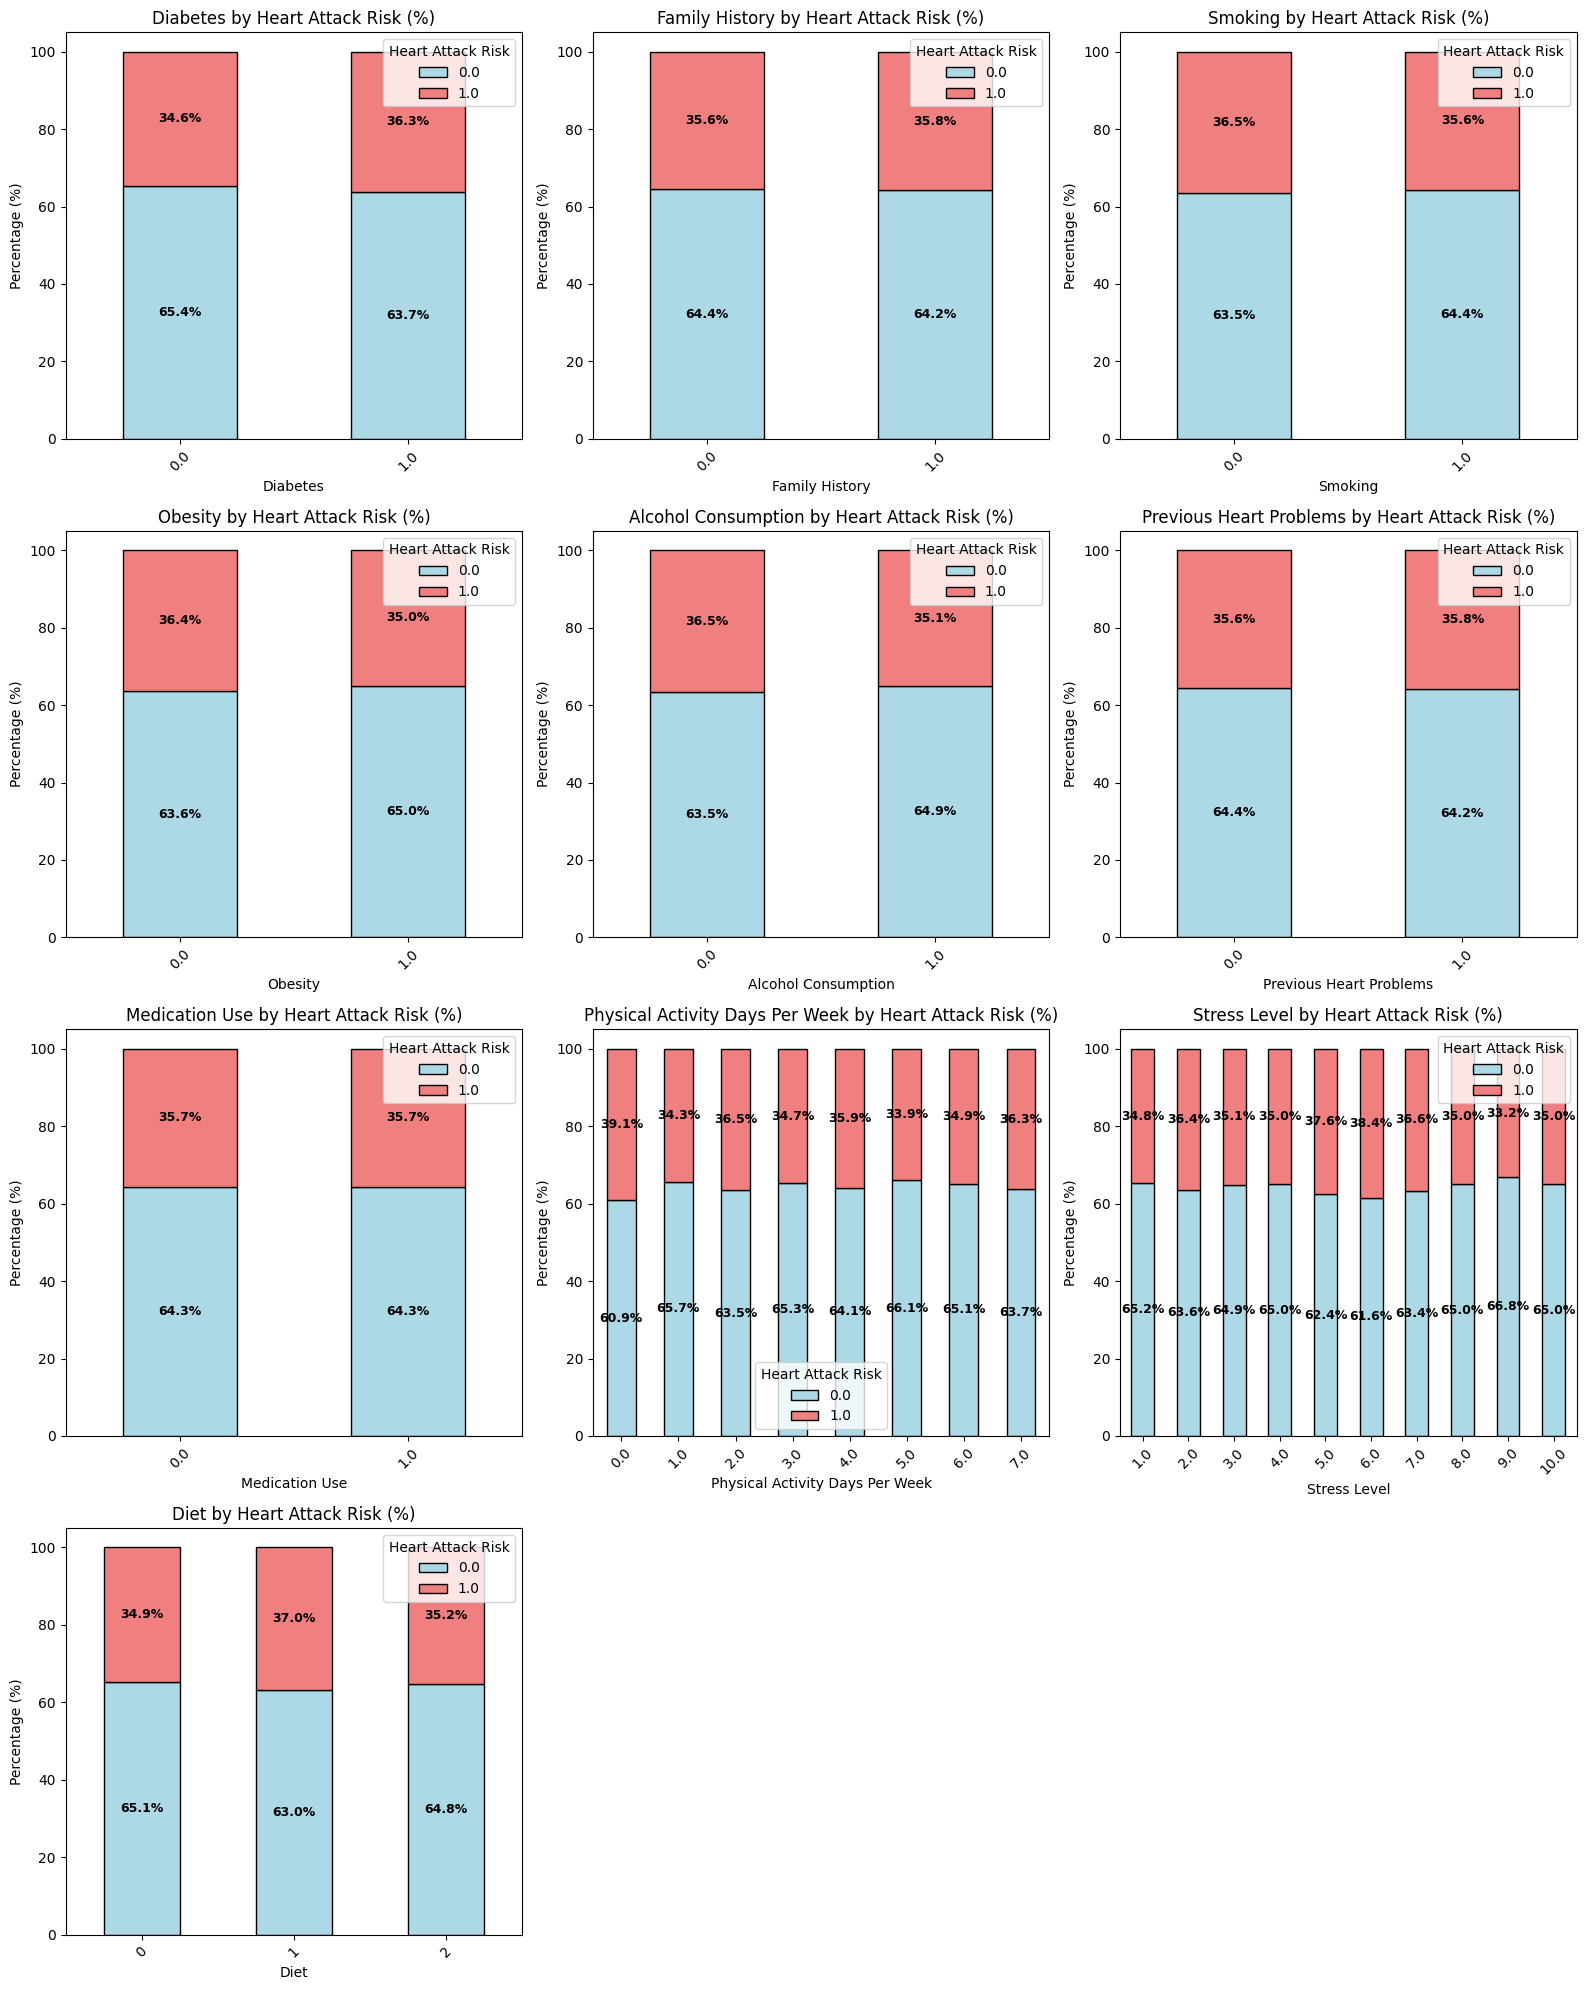

In [28]:
# Целевая переменная vs категориальные переменные
n_vars = len(object_col_2)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

plt.figure(figsize=(16, 5*n_rows))
for i, var in enumerate(object_col_2):
    plt.subplot(n_rows, n_cols, i+1)

    # Создаем таблицу сопряженности с процентами по строкам
    crosstab = pd.crosstab(df_eda[var], df_eda[target_col], normalize='index') * 100

    # Строим stacked bar plot
    crosstab.plot(kind='bar', stacked=True, ax=plt.gca(),
                  color=['lightblue', 'lightcoral'], edgecolor='black')

    plt.title(f'{var} by Heart Attack Risk (%)')
    plt.xlabel(var)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Heart Attack Risk')
    plt.xticks(rotation=45)

    # Добавляем подписи с процентами на столбцы
    ax = plt.gca()
    for container in ax.containers:
        ax.bar_label(container, labels=[f'{v:.1f}%' if v > 5 else '' for v in container.datavalues],
                    label_type='center', fontsize=9, color='black', weight='bold')

plt.tight_layout()
plt.show()

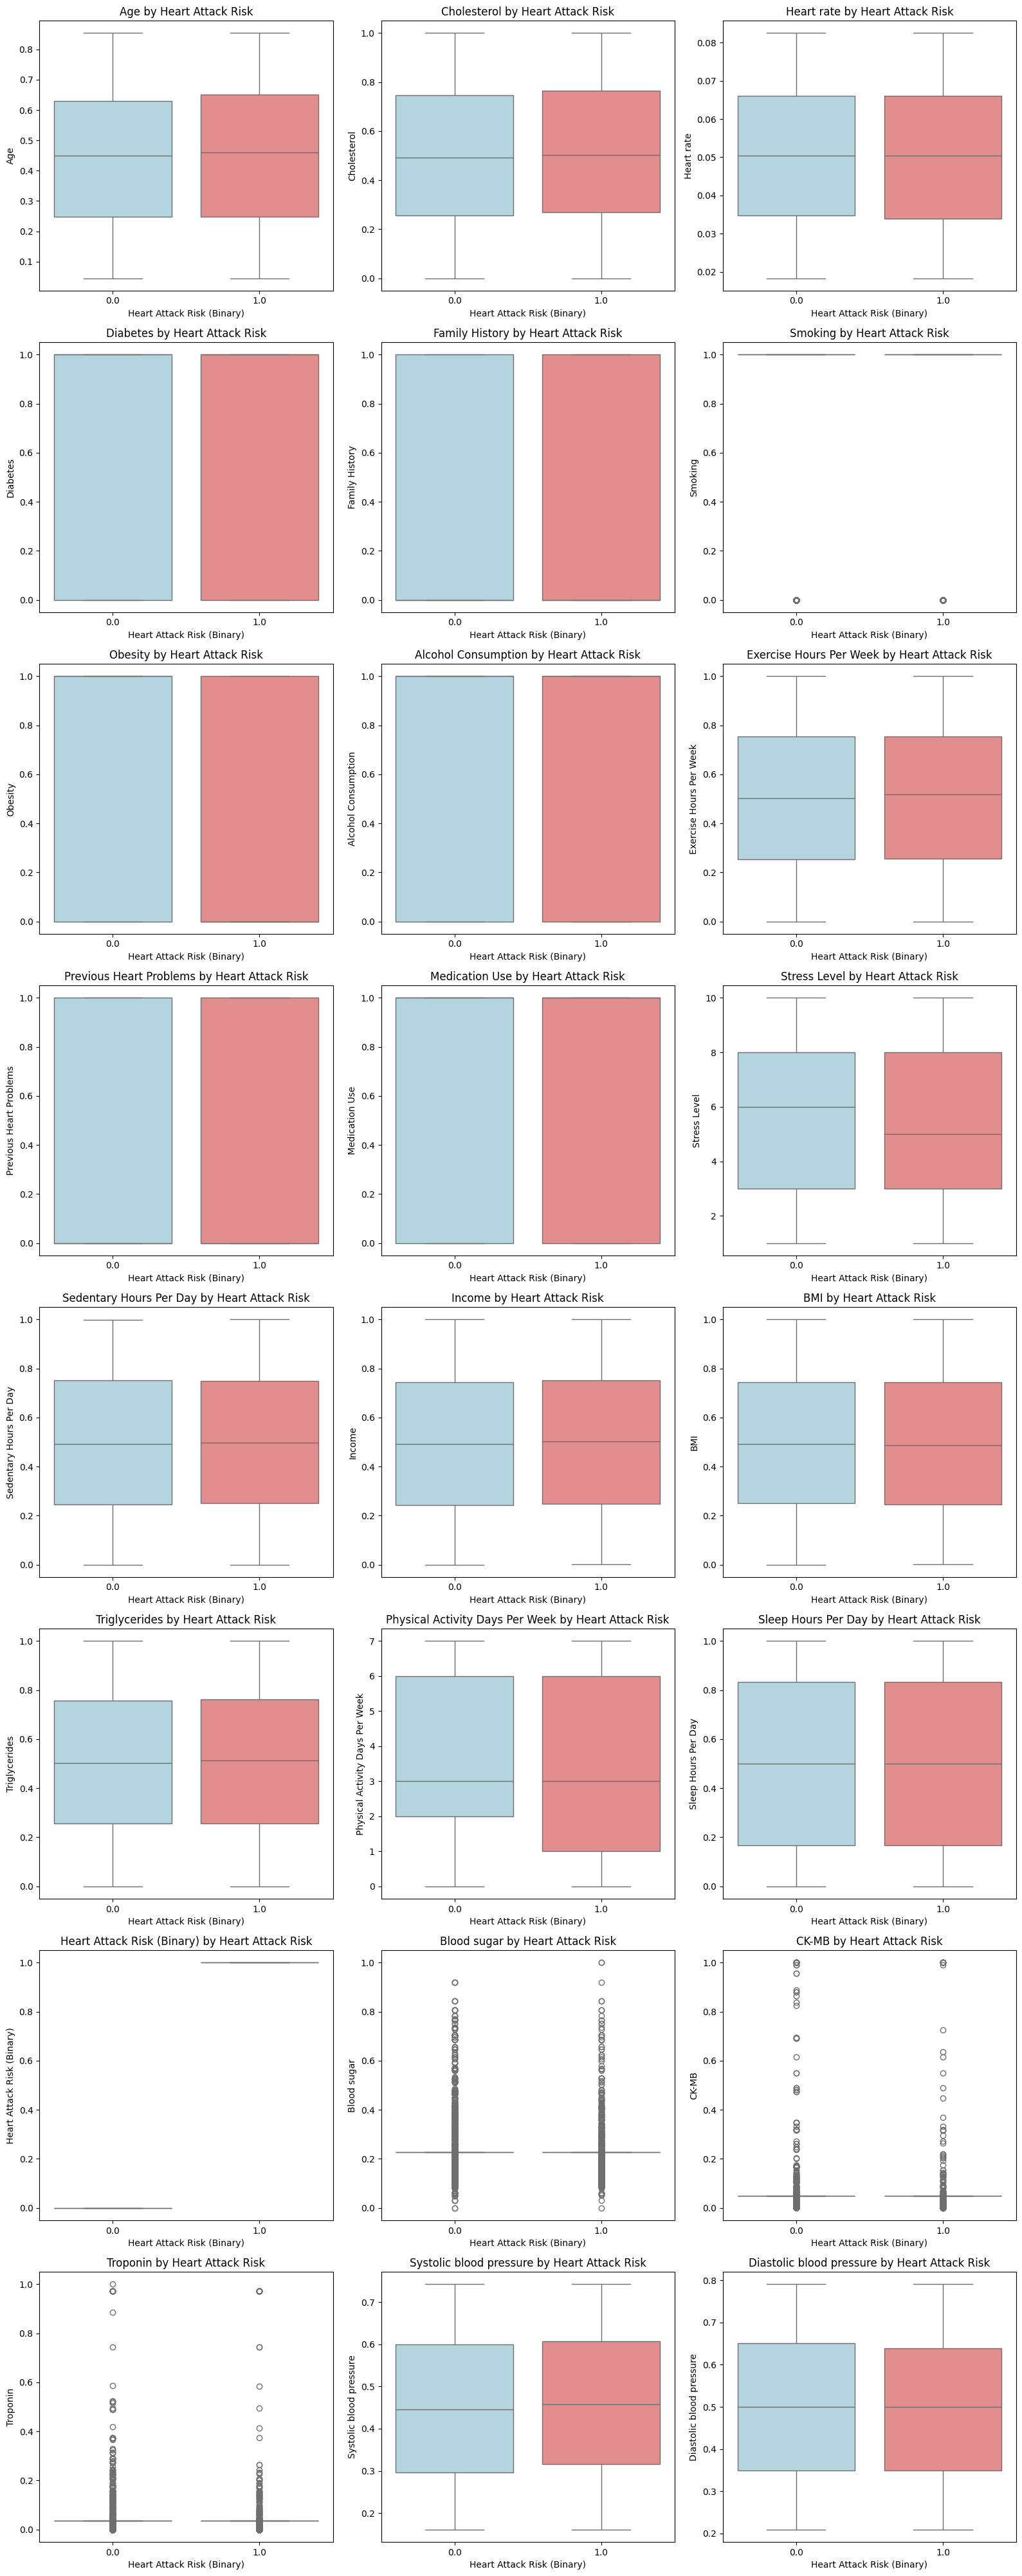

In [32]:
# Целевая переменная vs количественные переменные
num_col = df_eda.select_dtypes(include=float)
n_vars = len(num_col)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

plt.figure(figsize=(16, 5*n_rows))
for i, var in enumerate(num_col):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=target_col, y=var, hue=target_col, data=df_eda, palette=['lightblue', 'lightcoral'], legend=False)
    plt.title(f'{var} by Heart Attack Risk')
plt.tight_layout()
plt.show()

Анализ целевой переменной vs категориальные и количественные переменные не выявляется каих либо существенных графических различий.

Попробуем убрать выброс в сахаре (автозаполненные значения и посмотреть на результат)

In [11]:
# Новый дф
mode_sugar = df_eda['Blood sugar'].mode()[0]
df_new = df_eda[df_eda['Blood sugar'] != mode_sugar]

num_col_new = df_new.select_dtypes(include = float)
num_col_new.columns.tolist()

['Age',
 'Cholesterol',
 'Heart rate',
 'Exercise Hours Per Week',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Sleep Hours Per Day',
 'Heart Attack Risk (Binary)',
 'Blood sugar',
 'CK-MB',
 'Troponin',
 'Systolic blood pressure',
 'Diastolic blood pressure']

In [12]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1891 entries, 9287 to 5191
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   index                            1891 non-null   int64  
 1   Age                              1891 non-null   float64
 2   Cholesterol                      1891 non-null   float64
 3   Heart rate                       1891 non-null   float64
 4   Diabetes                         1891 non-null   object 
 5   Family History                   1891 non-null   object 
 6   Smoking                          1891 non-null   object 
 7   Obesity                          1891 non-null   object 
 8   Alcohol Consumption              1891 non-null   object 
 9   Exercise Hours Per Week          1891 non-null   float64
 10  Diet                             1891 non-null   int64  
 11  Previous Heart Problems          1891 non-null   object 
 12  Medication Use        

In [49]:
quantitative_description(df_new, num_col_new)

Описательная статистика по переменной: Age


,Age
count,1891.000000
mean,0.473954
std,0.148632
min,0.056180
25%,0.382022
50%,0.494382
75%,0.573034
max,0.853933


Описательная статистика по переменной: Cholesterol


,Cholesterol
count,1891.000000
mean,0.500761
std,0.289604
min,0.000000
25%,0.264286
50%,0.500000
75%,0.746429
max,1.000000


Описательная статистика по переменной: Heart rate


...

,Troponin
count,1891.000000
mean,0.038096
std,0.125279
min,0.000000
25%,0.000485
50%,0.001262
75%,0.009418
max,1.000000


Описательная статистика по переменной: Systolic blood pressure


,Systolic blood pressure
count,1891.000000
mean,0.452759
std,0.173309
min,0.161290
25%,0.296774
50%,0.451613
75%,0.606452
max,0.741935


Описательная статистика по переменной: Diastolic blood pressure


,Diastolic blood pressure
count,1891.000000
mean,0.495892
std,0.171118
min,0.209302
25%,0.348837
50%,0.488372
75%,0.639535
max,0.790698


**Вывод, что после удаления типичных значений по сахару:**

- улучшилась ситуация по переменным (появилась форма распределения, отдаленно напоминающая форму нормального распределения): возраст, сердечный ритм, сахар

- немного улучшилась ситуация по переменным: холестерол, доход,

- не улучшилась: часы упражнений в день, малоподвижные часы в день, ИМТ, триглицериды, часы сна в день, артериальное давление


In [47]:
nom_analysis(df_new)

После удаления типичного значения по сахару по категориальным переменным правдоподобность не улучшилась, но хорошая новость в том, что удаление не привело к увеличению дисбаланса классов по целевой переменной.

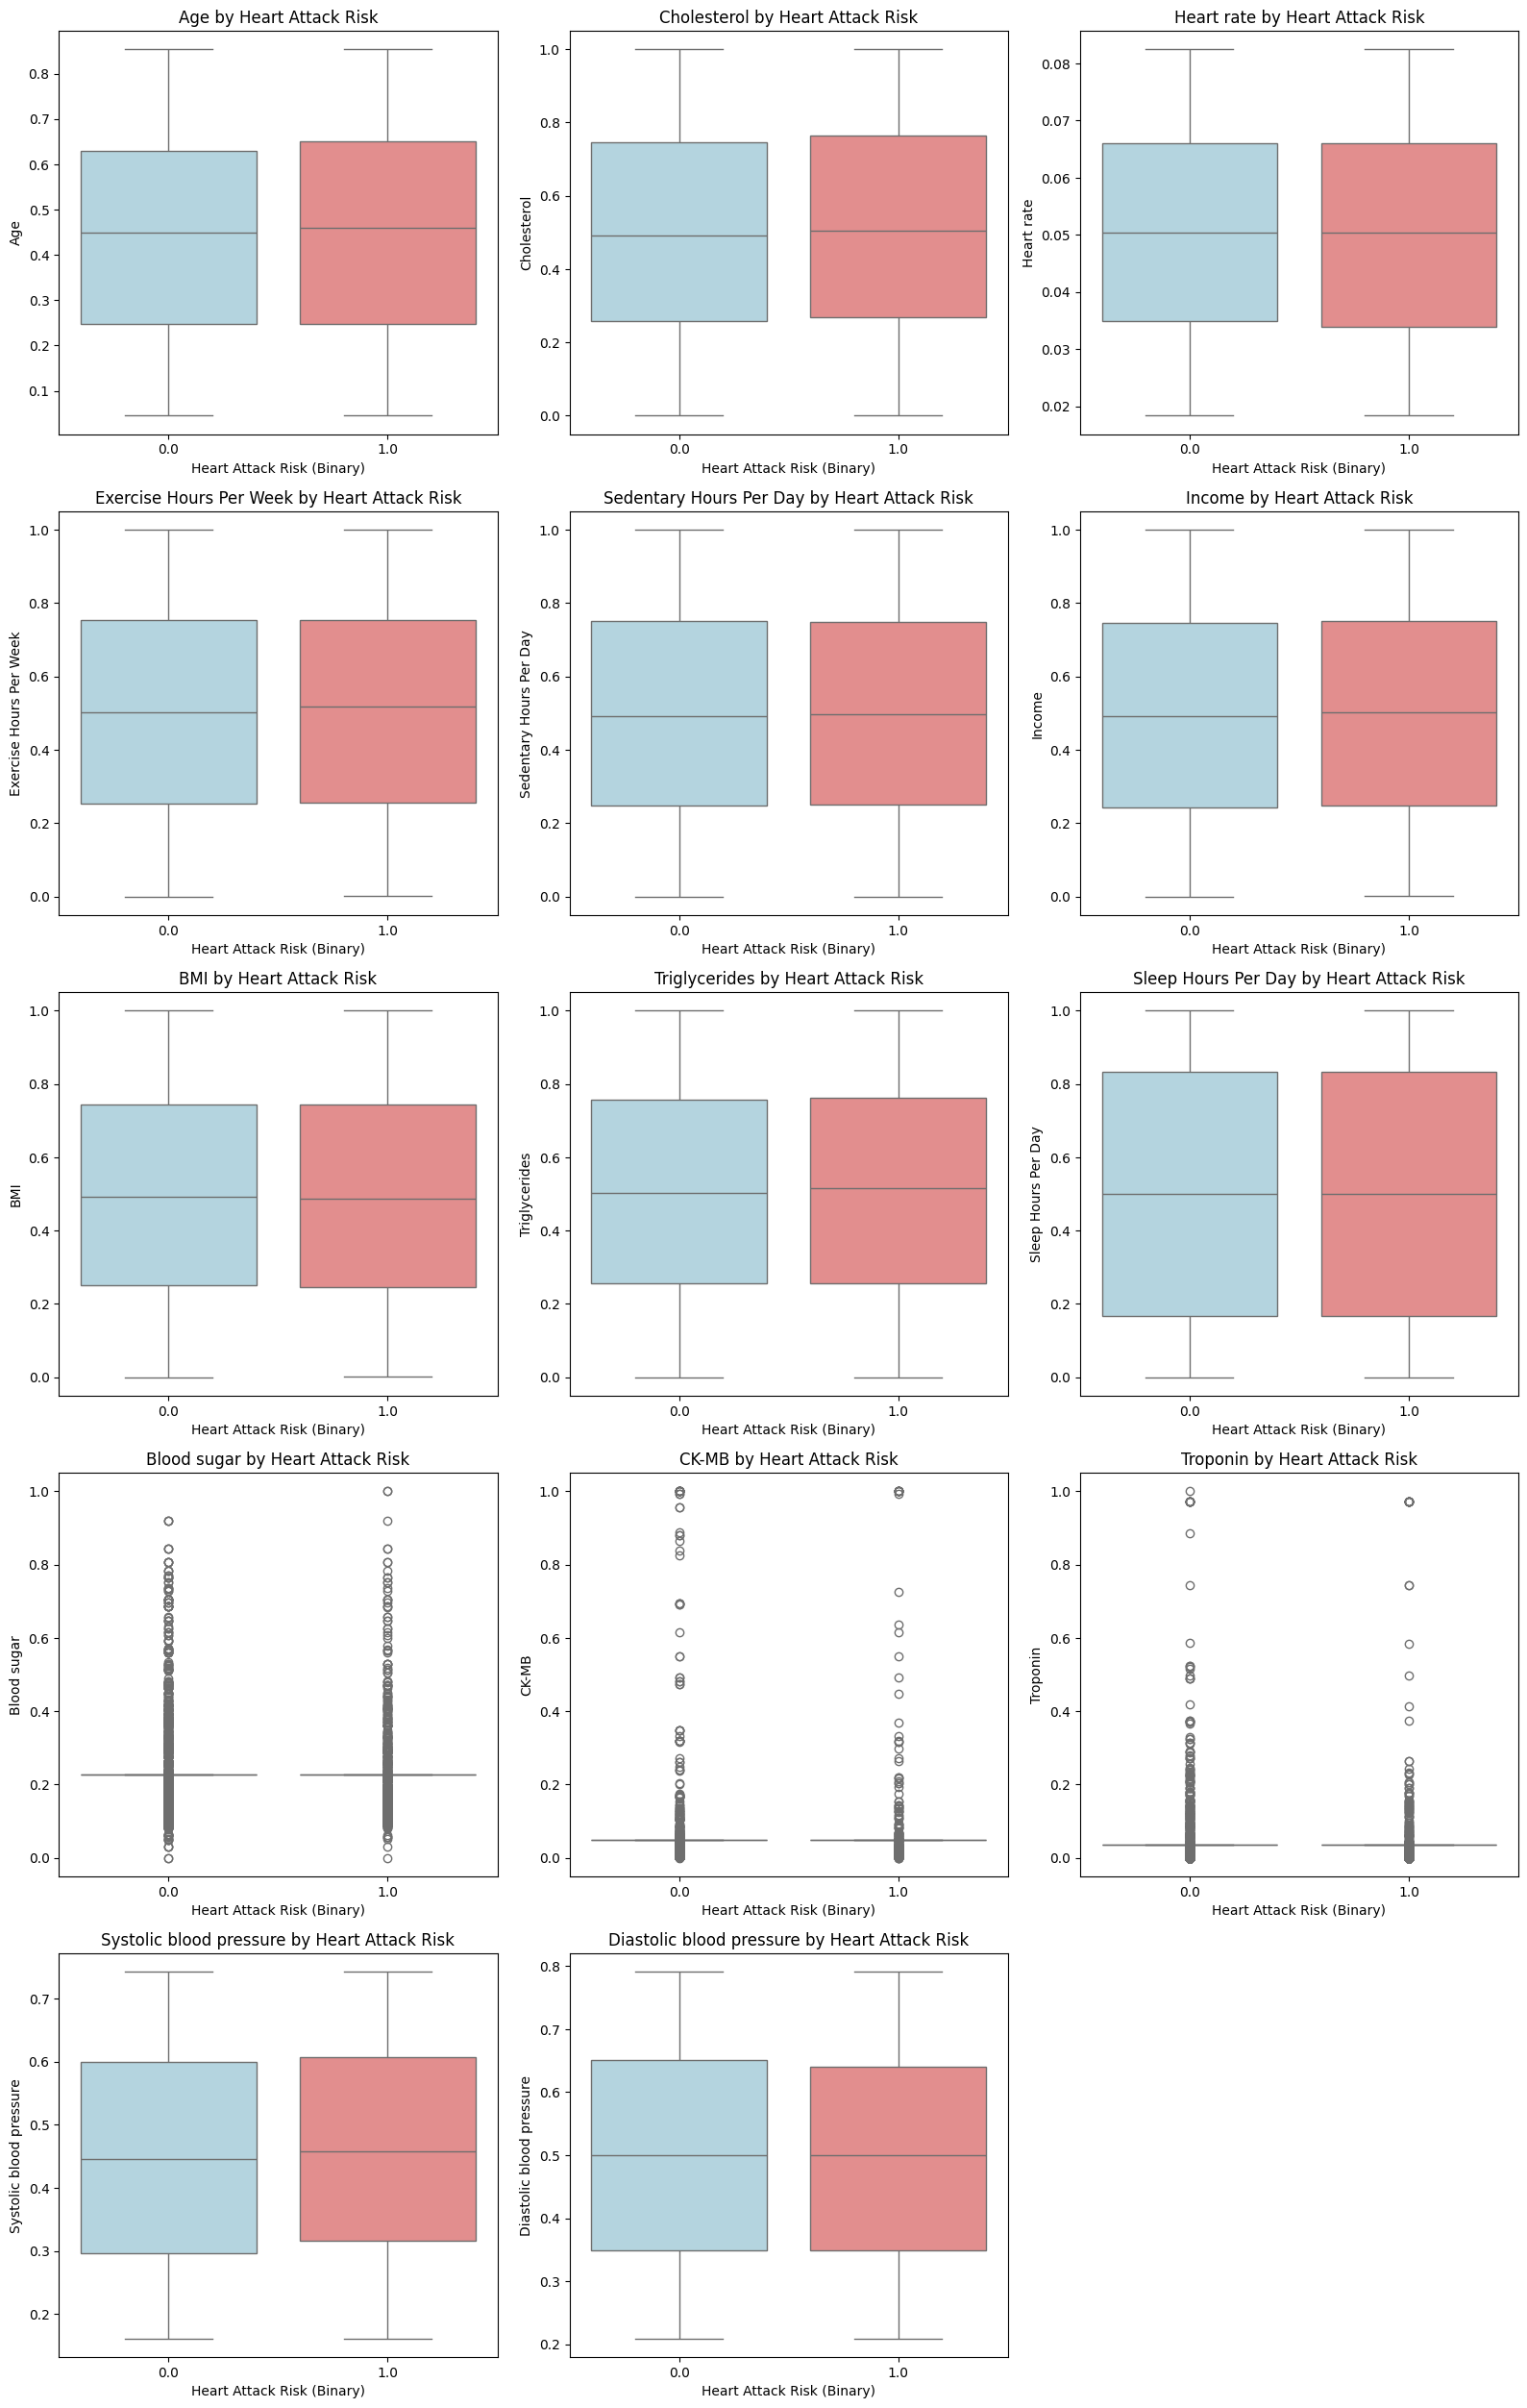

In [16]:
num_col_new = df_new.select_dtypes(include=float)
n_vars = len(num_col_new)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

plt.figure(figsize=(16, 5*n_rows))
for i, var in enumerate(num_col_new):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=target_col, y=var, hue=target_col, data=df_eda, palette=['lightblue', 'lightcoral'], legend=False)
    plt.title(f'{var} by Heart Attack Risk')
plt.tight_layout()
plt.show()

# Матрица корреляций

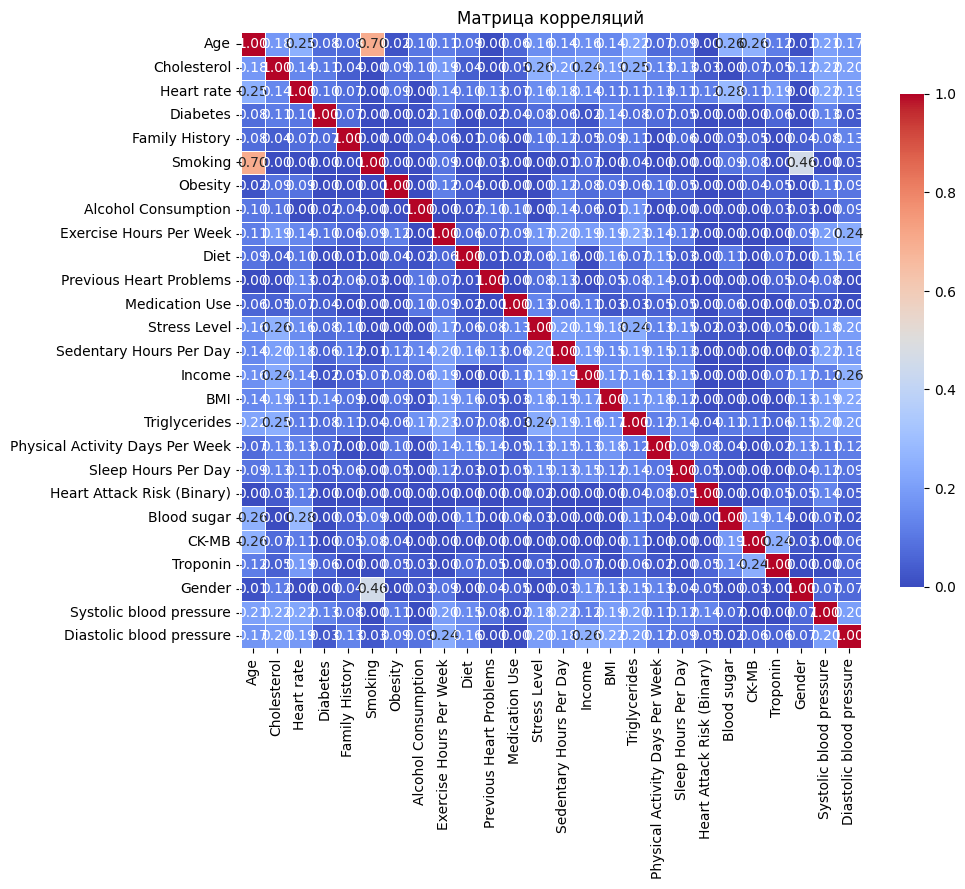

In [50]:
# Полная матрица корреляций
phik_matrix = df_new.iloc[:, 1:].phik_matrix(interval_cols=num_col)
plt.figure(figsize=(10, 8))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Матрица корреляций")
plt.show()

Высоких линейных корреляций с целевой переменной мы не наблюдаем. Есть достаточно высокая корреляция между курением, возрастом и полом, но можно эти переменные оставить в модели.

## Обучение моделей

In [13]:
# Создание класса подготовки данных для последующего использования в приложении, чтобы приложение могло работать с необработанными данными на вход

%%writefile heart_preprocessor.py

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import logging
from typing import List, Union, Optional

# Настройка логирования для отслеживания процесса
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class DataPreprocessor:
    def __init__(self):
        # Словарь категорий признаков для автоматической классификации
        self.feature_categories = {
            'numeric': [
                'age', 'cholesterol', 'heart_rate', 'exercise_hours_per_week', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'sleep_hours_per_day',\
                'systolic_blood_pressure', 'diastolic_blood_pressure'
            ],

            'ordinal': [
                'physical_activity_days_per_week', 'stress_level'
            ],
            'nominal': [
                'diet', 'gender', 'diabetes', 'family_history', 'alcohol_consumption','obesity', 'previous_heart_problems', 'medication_use', 'smoking'
            ]
        }

        # Категории для порядковых признаков
        self.ordinal_categories_mapping = {
            'physical_activity_days_per_week': ['0', '1', '2', '3', '4', '5', '6', '7'],
            'stress_level': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
        }

        # Служебные атрибуты
        self.pipeline = None
        self.fitted = False
        self.feature_names_ = None
        self.processing_features_ = None
        self.column_mapping_ = None

    def _standardize_column_names(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Стандартизация названий колонок для единообразия

        """
        X = X.copy()
        X.columns = (
            X.columns
            .str.lower()
            .str.replace(' ', '_')
            .str.replace(',', '_')
            .str.replace('-', '_')
            .str.replace('__', '_')
        )
        logger.info(f"Стандартизированы названия колонок: {list(X.columns)}")
        return X

    def _get_processing_features(self, data: pd.DataFrame) -> List[str]:
        """
        Выбор признаков для обработки на основе предопределенных категорий, чтобы не обрабатывать лишние, если они есть

        """
        if self.processing_features_ is not None:
            return self.processing_features_

        # Собираем все ожидаемые признаки из всех категорий
        all_expected_features = sum(self.feature_categories.values(), [])

        # Выбираем только присутствующие в данных признаки
        available_features = [col for col in all_expected_features if col in data.columns]

        # Проверяем и логируем отсутствующие признаки
        missing_features = set(all_expected_features) - set(available_features)
        if missing_features:
            logger.warning(f"Отсутствуют ожидаемые признаки: {missing_features}")

        logger.info(f"Для обработки выбрано {len(available_features)} признаков")
        return available_features

    def _auto_detect_feature_types(self, X: pd.DataFrame) -> tuple:
        """
        Верификация типов признаков на основе предопределенных категорий

        """
        processing_features = self._get_processing_features(X)

        # Инициализируем словарь для категоризированных признаков
        categorized_features = {category: [] for category in self.feature_categories.keys()}

        # Распределяем признаки по категориям
        for feature in processing_features:
            for category, features_list in self.feature_categories.items():
                if feature in features_list:
                    categorized_features[category].append(feature)
                    break

        # Извлекаем списки по категориям
        numeric_features = categorized_features['numeric']
        ordinal_features = categorized_features['ordinal']
        nominal_features = categorized_features['nominal']

        # Проверяем типы данных для числовых признаков
        for num_feature in numeric_features:
            if not pd.api.types.is_numeric_dtype(X[num_feature]):
                logger.warning(f"Признак {num_feature} помечен как числовой, но имеет тип {X[num_feature].dtype}")

        logger.info(
            f"Распределение признаков: {len(numeric_features)} числовых, "
            f"{len(ordinal_features)} порядковых, "
            f"{len(nominal_features)} номинальных"
        )

        return numeric_features, ordinal_features, nominal_features

    def _get_ordinal_categories(self, ordinal_features: List[str]) -> List[List[str]]:
        """
        Получение категорий для порядкового кодирования

        """
        ordinal_categories = []

        for col in ordinal_features:
            if col in self.ordinal_categories_mapping:
                ordinal_categories.append(self.ordinal_categories_mapping[col])
                logger.debug(f"Для {col} использованы предопределенные категории")
            else:
                # Для неизвестных порядковых признаков используем сортированные уникальные значения
                logger.warning(f"Для порядкового признака {col} не найдены предопределенные категории")
                ordinal_categories.append(None)  # Будет определено автоматически

        return ordinal_categories

    def _create_preprocessing_pipeline(self, numeric_features: List[str],
                                     ordinal_features: List[str],
                                     nominal_features: List[str]) -> ColumnTransformer:
        """
        Создание комплексного пайплайна предобработки

        """
        transformers = []

        # Трансформер для числовых признаков
        if numeric_features:
            numeric_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ])
            transformers.append(('num', numeric_transformer, numeric_features))
            logger.info(f"Создан трансформер для {len(numeric_features)} числовых признаков")

        # Трансформер для порядковых признаков
        if ordinal_features:
            ordinal_categories = self._get_ordinal_categories(ordinal_features)
            ordinal_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown='use_encoded_value',
                    unknown_value=-1
                ))
            ])
            transformers.append(('ordinal', ordinal_transformer, ordinal_features))
            logger.info(f"Создан трансформер для {len(ordinal_features)} порядковых признаков")

        # Трансформер для номинальных признаков
        if nominal_features:
            nominal_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False,
                    drop='first'
                ))
            ])
            transformers.append(('nominal', nominal_transformer, nominal_features))
            logger.info(f"Создан трансформер для {len(nominal_features)} номинальных признаков")

        # Создаем ColumnTransformer
        if transformers:
            preprocessor = ColumnTransformer(
                transformers=transformers,
                remainder='drop',
                n_jobs=-1
            )
            logger.info("Создан комплексный пайплайн предобработки")
        else:
            preprocessor = 'passthrough'
            logger.warning("Не создано трансформеров - используется passthrough")

        return preprocessor

    def _save_feature_names(self, numeric_features: List[str],
                          ordinal_features: List[str],
                          nominal_features: List[str]) -> None:
        """
        Сохранение имен признаков после трансформации

        """
        feature_names = []

        feature_names.extend(numeric_features)

        feature_names.extend(ordinal_features)

        if nominal_features and hasattr(self.pipeline, 'named_transformers_'):
            nominal_transformer = self.pipeline.named_transformers_.get('nominal')
            if nominal_transformer is not None and hasattr(nominal_transformer, 'named_steps'):
                ohe_encoder = nominal_transformer.named_steps['encoder']
                nominal_feature_names = ohe_encoder.get_feature_names_out(nominal_features)
                feature_names.extend(nominal_feature_names)
                logger.info(f"One-hot кодирование создало {len(nominal_feature_names)} фич из {len(nominal_features)} номинальных признаков")

        self.feature_names_ = feature_names
        logger.info(f"Сохранено {len(feature_names)} имен признаков после трансформации")

    def _process_target_variable(self, y: pd.Series) -> pd.Series:
        """
        Обработка целевой переменной - перевод в тип bool
        """
        if y is not None:
            y_processed = y.astype(bool)
            logger.info(f"Целевая переменная преобразована в bool. Уникальные значения: {y_processed.unique()}")
            return y_processed
        return y

    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> 'DataPreprocessor':
        """
        Обучение препроцессора на данных

        """
        logger.info("Начало обучения препроцессора...")

        y_processed = self._process_target_variable(y)

        # Стандартизация названий колонок
        X_processed = self._standardize_column_names(X)

        # Определение признаков для обработки
        self.processing_features_ = self._get_processing_features(X_processed)
        X_for_processing = X_processed[self.processing_features_].copy()

        # Автоматическое определение типов признаков
        numeric_features, ordinal_features, nominal_features = \
            self._auto_detect_feature_types(X_for_processing)

        # Создание и обучение пайплайна
        self.pipeline = self._create_preprocessing_pipeline(
            numeric_features, ordinal_features, nominal_features
        )

        self.pipeline.fit(X_for_processing, y)
        self.fitted = True

        # Сохранение имен признаков после трансформации
        self._save_feature_names(numeric_features,
                               ordinal_features, nominal_features)

        logger.info("✅ Препроцессор успешно обучен!")
        return self

    def transform(self, X: pd.DataFrame) -> np.ndarray:

        if not self.fitted:
            raise RuntimeError("Сначала обучите препроцессор методом fit()!")

        X_processed = self._standardize_column_names(X)
        X_for_processing = X_processed[self.processing_features_].copy()

        result = self.pipeline.transform(X_for_processing)

        logger.info(f"✅ Данные успешно трансформированы. Форма: {result.shape}")
        return result

    def fit_transform(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> np.ndarray:
        y_processed = self._process_target_variable(y)

        return self.fit(X, y).transform(X)

    def get_feature_names_out(self, input_features: Optional[List[str]] = None) -> List[str]:

        if not self.fitted:
            raise RuntimeError("Сначала обучите препроцессор методом fit()!")

        if self.feature_names_ is None:
            raise RuntimeError("Имена признаков не сохранены. Проверьте процесс обучения.")

        return self.feature_names_.copy()


Overwriting heart_preprocessor.py


In [14]:
# Разделение трейн датасета
X = df_new.drop('Heart Attack Risk (Binary)', axis=1)
y = df_new['Heart Attack Risk (Binary)']

In [15]:
# Разделение на обучающую и валидационную выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Распределение целевой переменной:")
print(f"   Train: {y_train.value_counts().to_dict()}")
print(f"   Test:  {y_test.value_counts().to_dict()}")

Train set: (1418, 26)
Test set: (473, 26)
Распределение целевой переменной:
   Train: {0.0: 941, 1.0: 477}
   Test:  {0.0: 314, 1.0: 159}


In [16]:
# предобработка
from heart_preprocessor import DataPreprocessor
preprocessor = DataPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
print(f"Train данные после обработки: {X_train_processed.shape}")
X_test_processed = preprocessor.transform(X_test)
print(f"Test данные после обработки: {X_test_processed.shape}")

Train данные после обработки: (1418, 23)
Test данные после обработки: (473, 23)


In [17]:
print("\n Фичи используемые в модели:")
feature_names = preprocessor.get_feature_names_out()
print(f"Всего фич в модели: {len(feature_names)}")
print("Список фич:")
for i, feature in enumerate(feature_names, 1):
    print(f"  {i:2d}. {feature}")


 Фичи используемые в модели:
Всего фич в модели: 23
Список фич:
   1. age
   2. cholesterol
   3. heart_rate
   4. exercise_hours_per_week
   5. sedentary_hours_per_day
   6. income
   7. bmi
   8. triglycerides
   9. sleep_hours_per_day
  10. systolic_blood_pressure
  11. diastolic_blood_pressure
  12. physical_activity_days_per_week
  13. stress_level
  14. diet_1
  15. diet_2
  16. gender_Male
  17. diabetes_1.0
  18. family_history_1.0
  19. alcohol_consumption_1.0
  20. obesity_1.0
  21. previous_heart_problems_1.0
  22. medication_use_1.0
  23. smoking_1.0


In [18]:
# параметры моделей

models = {
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'LogisticRegression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE)
}


param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', None]
    },

    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [4, 6],
        'learning_rate': [0.1, 0.2],
        'subsample': [0.8, 1.0]
    },

    'LightGBM': {
        'n_estimators': [100, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.1, 0.2],
        'num_leaves': [31, 50]
    },

    'GradientBoosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.1, 0.2],
        'max_depth': [3, 4],
        'min_samples_split': [2, 5]
    },

    'LogisticRegression': {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },

    'DecisionTree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 10],
        'criterion': ['gini', 'entropy']
    }
}

In [21]:
# Стратегия кросс-валидации
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Хранение результатов
best_models = {}
cv_results = {}
test_metrics = {}

In [19]:
# статистика по моделям
def evaluate_model(model, X_test, y_test, model_name=""):

    # Предсказания
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Основные метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Вывод результатов
    print(f"{model_name} - Метрики:")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"ROC-AUC:   {roc_auc:.3f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc
    }


Целевая метрика: в качестве целевой метрики выбираем roc_auc, потому что нам важны и recall (не пропустить тех пациентов, у которых есть риски, т.к. последствия такого пропуска могут быть критичными), и precision (не отправлять со слишком большим запасом пациентов на доп.диагностику, т.к. это создает высокие затраты). Но при выборе порога будем больше ориентироваться на recall

In [37]:
# обучение и оценка качества моделей
for model_name, model in models.items():
    print(f"\n Настраиваю {model_name}...")
    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_processed, y_train)

    end_time = time.time()


    best_models[model_name] = grid_search.best_estimator_

    test_metrics[model_name] = evaluate_model(
            best_models[model_name],
            X_test_processed,
            y_test,
            model_name)

    cv_results[model_name] = {
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'time': end_time - start_time,
            **test_metrics[model_name]
        }


    print(f" {model_name}: точность {grid_search.best_score_:.3f}, время {end_time - start_time:.1f}с")




 Настраиваю RandomForest...
RandomForest - Метрики:
Accuracy:  0.761
Precision: 0.911
Recall:    0.321
ROC-AUC:   0.795
 RandomForest: точность 0.775, время 166.2с

 Настраиваю XGBoost...
XGBoost - Метрики:
Accuracy:  0.738
Precision: 0.652
Recall:    0.472
ROC-AUC:   0.761
 XGBoost: точность 0.757, время 22.4с

 Настраиваю LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM - Метрики:
Accuracy:  0.719
Precision: 0.616
Recall:    0.434
ROC-AUC:   0.759
 LightGBM: точность 0.755, время 45.0с

 Настраиваю GradientBoosting...
GradientBoosting - Метрики:
Accuracy:  0.719
Precision: 0.602
Recall:    0.484
ROC-AUC:   0.750
 GradientBoosting: точность 0.736, время 84.1с

 Настраиваю LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LogisticRegression - Метрики:
Accuracy:  0.664
Precision: 0.000
Recall:    0.000
ROC-AUC:   0.496
 LogisticRegression: точность 0.525, время 3.9с

 Настраиваю DecisionTree...
DecisionTree - Метрики:
Accuracy:  0.672
Precision: 0.512
Recall:    0.516
ROC-AUC:   0.682
 DecisionTree: точность 0.683, время 1.3с


**Итог:** выбираем модель RandomForest, потому что у нее самые лучшие метрики

In [38]:
# Выбор модели
best_model = best_models['RandomForest']
best_estimator_dt = best_models['RandomForest']

Оптимальный порог: 0.225
При этом пороге:
   Precision: 0.460
   Recall:    0.981
   F1-score:  0.627


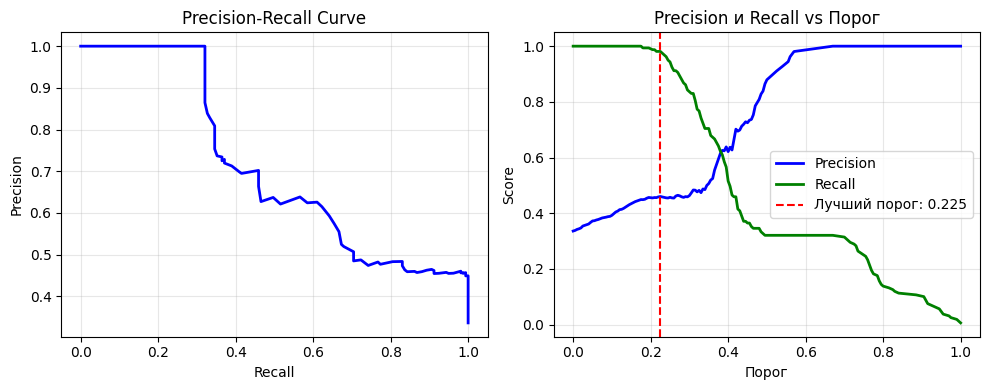

In [39]:
# Выбор порога
y_pred_proba = best_model.predict_proba(X_test_processed)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"При этом пороге:")
print(f"   Precision: {precisions[best_idx]:.3f}")
print(f"   Recall:    {recalls[best_idx]:.3f}")
print(f"   F1-score:  {f1_scores[best_idx]:.3f}")

# Визуализация
plt.figure(figsize=(10, 4))

# Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, 'b-', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True, alpha=0.3)

# Precision и Recall vs Threshold
plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], 'b-', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Лучший порог: {best_threshold:.3f}')
plt.xlabel('Порог')
plt.ylabel('Score')
plt.title('Precision и Recall vs Порог')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**Итог:** предлагаю выбрать порог 0.3, потому что он еще дает приемлемый recall и повышает немного precision

Важность признаков:
                     feature  importance
4    sedentary_hours_per_day    0.093073
5                     income    0.087423
1                cholesterol    0.085625
9    systolic_blood_pressure    0.085074
3    exercise_hours_per_week    0.084815
6                        bmi    0.083925
7              triglycerides    0.082386
0                        age    0.077561
10  diastolic_blood_pressure    0.075167
2                 heart_rate    0.073496


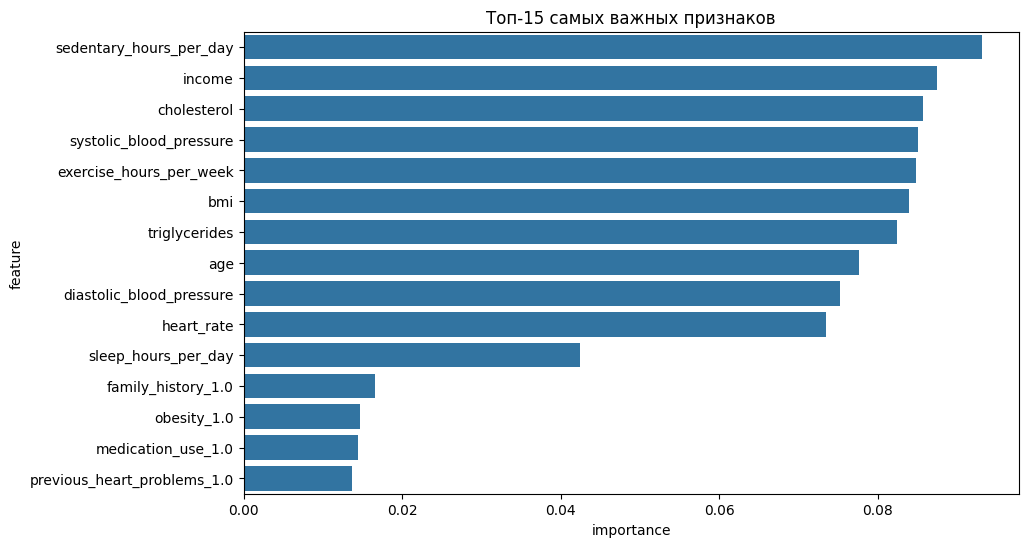

In [41]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': preprocessor.get_feature_names_out(),
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Важность признаков:")
    print(feature_importance.head(10))

    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title('Топ-15 самых важных признаков')
    plt.show()

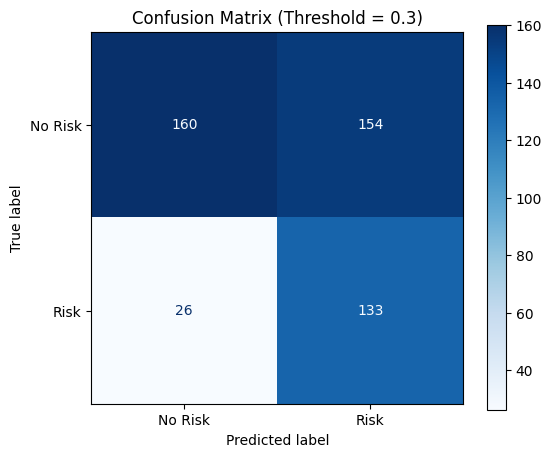

In [45]:
# Применяем лучший порог на практике
def predict_with_threshold(model, X, threshold):
    probas = model.predict_proba(X)[:, 1]
    return (probas >= threshold).astype(int)

# Применение
y_pred_custom = predict_with_threshold(best_model, X_test_processed, threshold=0.3)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'Risk'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Threshold = 0.3)')
plt.show()

**Общий вывод по модели:** модель в целом получилась не очень высокого качества. ROC-AUC максимально 80%, а precision будет на уровне 46%, то есть 54% пациентов будут напрасно направлены на диагностику. Такое качество модели, на мой взгляд, обусловлено:

- вопросами относительно репрезентативности и распределения ряда переменных в исходных данных

- самой природой изучаемого явления, потому что сердечный приступ является острым состоянием, которое иногда необъяснимо развивается внезапно (с одной стороны), но может и не наступить при наличии всех факторов риска (с другой стороны)

In [46]:
# Сохраняем модель для приложения (функция)
def save_trained_artifacts(preprocessor, model, threshold=0.3):

    preprocessor_path = '/content/drive/MyDrive/heart_model/preprocessor.pkl'
    model_path = '/content/drive/MyDrive/heart_model/model.pkl'

    # Сохраняем
    joblib.dump(preprocessor, preprocessor_path)
    joblib.dump(model, model_path)

    metadata = {
        'model_name': type(model).__name__,
        'threshold': threshold,
        'preprocessor_path': preprocessor_path,
        'model_path': model_path
    }

    print("Сохранено в Google Drive:")
    print(f"Модель: {type(model).__name__}")
    print(f"Путь: {model_path}")

    return metadata




In [47]:
# Сохраняем реальные артефакт
metadata = save_trained_artifacts(
    preprocessor=preprocessor,
    model=best_models['RandomForest'],
    threshold=0.3)

Сохранено в Google Drive:
Модель: RandomForestClassifier
Путь: /content/drive/MyDrive/heart_model/model.pkl


In [48]:
# Класс для предсказания для использования в модели

%%writefile heart_predictor.py

import joblib
import pandas as pd
import numpy as np
import json
from sklearn.ensemble import RandomForestClassifier

class HeartRiskPredictor:

    def __init__(self, preprocessor_path, model_path):
        self.preprocessor = joblib.load(preprocessor_path)
        self.model = joblib.load(model_path)
        self.threshold = 0.3
        self.is_fitted = True

    def predict_proba(self, data):
        """Возвращает вероятности классов"""
        processed_data = self.preprocessor.transform(data)
        return self.model.predict_proba(processed_data)

    def predict(self, data, threshold=None):
        if threshold is None:
            threshold = self.threshold

        probabilities = self.predict_proba(data)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        result = {
            'predictions': predictions.tolist(),
            'probabilities': probabilities.tolist(),
            'threshold': threshold,
            'model_type': type(self.model).__name__
        }

        return result


Writing heart_predictor.py


In [55]:
from heart_predictor import HeartRiskPredictor

predictor = HeartRiskPredictor(
    preprocessor_path='/content/drive/MyDrive/heart_model/preprocessor.pkl',
    model_path='/content/drive/MyDrive/heart_model/model.pkl'
)

prediction_result = predictor.predict(df_test, threshold=0.3)

predictions = prediction_result['predictions']

result_df = pd.DataFrame({'predicted_class': predictions}, index=df_test.index)

print(f"Доля класса 1: {result_df['predicted_class'].mean():.3f}")
print(f"Всего строк: {len(result_df)}")
print(f"Класс 1: {result_df['predicted_class'].sum()}")
print(f"Класс 0: {len(result_df) - result_df['predicted_class'].sum()}")

drive_path = '/content/drive/MyDrive/heart_risk_predictions.csv'
result_df.to_csv(drive_path, index=True)

Доля класса 1: 0.752
Всего строк: 966
Класс 1: 726
Класс 0: 240


In [ ]:
!cp heart_preprocessor.py '/content/drive/MyDrive/heart_model/'
print("Файл сохранен в Google Drive")

Файл сохранен в Google Drive


In [ ]:
!cp heart_predictor.py '/content/drive/MyDrive/heart_model/'
print("Файл сохранен в Google Drive")

Файл сохранен в Google Drive
